In [116]:
import pandas as pd
import csv
import zipfile

In [117]:

df = pd.read_csv('./4G5G_trr_trs_20000.csv/4G5G_trr_trs_20000.csv', low_memory=False)

In [118]:
print(df.head(3))

  General.Eriref Faulty product.Design Responsible MHO  \
0        HZ38812                               RCS-DEV   
1        HZ38535                               CAT-IPT   
2        HZ38006                               RADIOSW   

  General.Submitter priority  \
0                          B   
1                          B   
2                          A   

                                     General.Heading  \
0  Emergency Unlock does not unlock the capacitie...   
1  MB G2 Mixed Mode C2 - Alarm Resource Activatio...   
2  MR8384 DOT4455 FFI:IRU1649 SW error alarm and ...   

                             Observation.Observation  \
0  1 E F F E C T \n============\n1.1\tTrouble sum...   
1  1 E F F E C T\n============\n1.1 Trouble summa...   
2  1 E F F E C T \n============\n1.1\tTrouble sum...   

                                       Answer.Answer  General.Is duplicate TR  \
0  CAUSE OF FAULT\n------------------------------...                    False   
1  CAUSE OF FAULT\n-------

In [119]:
print(len(df))

22293


In [120]:
df = df.drop(columns=['Before_assign','Before_last_assign','Accept_or_Cancelled','routing_time','routing_waiting_time','total_routing_time','total_time','routed'])
df = df.drop(columns=["to_radionode", "Registered", "General.Status explanation", "Answer.Answer", "TR History Register.Register date"])

In [121]:
missing_values_count = df.isnull().sum()
print(missing_values_count)

General.Eriref                                      0
Faulty product.Design Responsible MHO               0
General.Submitter priority                          0
General.Heading                                     0
Observation.Observation                            10
General.Is duplicate TR                             0
General.Primary TR                              18987
General.Duplicate TRs                           17274
General.Superior MHO                               96
General.Status code                                 0
Observation.Fault type                          16148
Analysis.Fault type                             21840
Improvement.Type explanation                    21125
Network level.Product no                        22293
Network level.Product no & R-State              22293
Node level.Product no                               5
Node level.Product no & R-State                     5
Node component level.Product no                 22111
Node component level.Product

In [122]:
import json
with open('4G5G_trr_trs_20000_MHO_Groups.json', 'r') as file:
    json_data = json.load(file)

#print(json.dumps(data, indent=4))
count = len(json_data)
print(count)

18


In [123]:
#lets check how many unique lebels are there// Faulty product.Design Responsible MHO
unique_values_count_mho = df['Faulty product.Design Responsible MHO'].nunique()
print(unique_values_count_mho)

222


In [124]:
def mho_from_json(json_str):
    try:
        #json_obj = json.loads(json_str)  # Parse JSON string into a Python dictionary
        for key, value in json_data.items():
            if json_str in value:
                return key
        return json_str
        #return list(json_data.keys())     # Return the keys as a list
    except json.JSONDecodeError:
        return []  # Return an empty list if parsing fails
    

df['subsystem_mho'] = df['Faulty product.Design Responsible MHO'].apply(mho_from_json)

In [125]:
columns_to_display = ['General.Eriref', 'Faulty product.Design Responsible MHO', 'subsystem_mho']
rows_to_display = df.iloc[:3]
print(rows_to_display[columns_to_display])

  General.Eriref Faulty product.Design Responsible MHO subsystem_mho
0        HZ38812                               RCS-DEV       RCS-DEV
1        HZ38535                               CAT-IPT        CAT-SW
2        HZ38006                               RADIOSW       RADIOSW


In [126]:
unique_values_count_submho = df['subsystem_mho'].nunique()
print(unique_values_count_submho)

#not_in_subsytem = []

#for value in df['subsystem_mho']:
#    if value not in json_data:
        #print(value)

33


In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

In [128]:
#lets drop other columns except a few
columns_to_keep = ['General.Heading', 'Observation.Observation', 'General.Submitter priority', 'subsystem_mho']
#df_filtered = df[columns_to_keep]
df.drop(columns=[col for col in df.columns if col not in columns_to_keep], inplace=True)
missing_values_count_filtered = df.isnull().sum()
print(missing_values_count_filtered)

General.Submitter priority     0
General.Heading                0
Observation.Observation       10
subsystem_mho                  0
dtype: int64


In [129]:
#Lets drop 10 rows of Observation
df = df.dropna(subset=['Observation.Observation'])
missing_values_count_filtered = df.isnull().sum()
print(missing_values_count_filtered)
print(len(df))
#print(df.head(2))

General.Submitter priority    0
General.Heading               0
Observation.Observation       0
subsystem_mho                 0
dtype: int64
22283


In [130]:
label_encoder = LabelEncoder()

# Encode categorical variables
df['General.Submitter priority'] = label_encoder.fit_transform(df['General.Submitter priority'])
#df['subsystem_mho'] = label_encoder.fit_transform(df['subsystem_mho'])  # Target encoding

# Convert text columns into numerical TF-IDF features
text_columns = ['General.Heading', 'Observation.Observation']

# Convert each text column into a TF-IDF matrix
tfidf_vectorizers = {}
tfidf_matrices = []

for col in text_columns:
    tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
    tfidf_matrix = tfidf_vectorizer.fit_transform(df[col].astype(str))
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(tfidf_matrix.shape[1])])
    #tfidf_vectorizers[col] = tfidf_vectorizer  # Store vectorizer for later use
    tfidf_matrices.append(tfidf_matrix)  # Store TF-IDF matrix



In [131]:
#print(tfidf_df.head(2))

In [132]:
# Transform text columns using TF-IDF and compute mean TF-IDF score per row
for col in text_columns:
    tfidf_matrix = tfidf_vectorizer.fit_transform(df[col].astype(str))
    df[f"{col}_tfidf_mean"] = np.mean(tfidf_matrix.toarray(), axis=1)  # Mean TF-IDF per row

['General.Submitter priority', 'subsystem_mho', 'General.Heading_tfidf_mean', 'Observation.Observation_tfidf_mean']


<ipython-input-133-6882698d02f5>:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = correlation_data.corr()


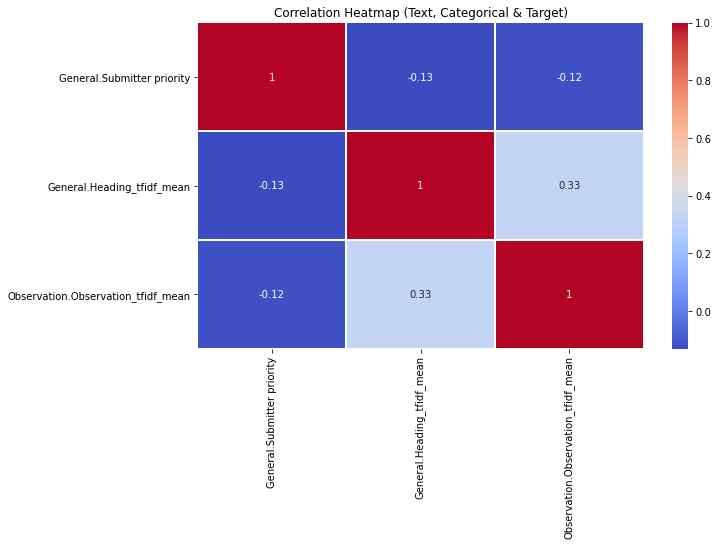

In [133]:
categorical_cols = ['General.Submitter priority']
target_col = ['subsystem_mho']

# Keep only relevant columns for correlation
selected_columns = categorical_cols + target_col + [f"{col}_tfidf_mean" for col in text_columns]
print(selected_columns)
#correlation_data = df[categorical_cols + [target_col] + [f"{col}_tfidf_mean" for col in text_columns]]
correlation_data = df[selected_columns]
# Compute correlation matrix
corr_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Text, Categorical & Target)")
plt.show()

In [134]:
import re
# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-z\s]", "", text)  # Keep only English letters and spaces
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

df["heading_clean"] = df["General.Heading"].apply(clean_text)
df["obervation_clean"] = df["Observation.Observation"].apply(clean_text)

# Combine both cleaned columns into one for TF-IDF
df["combined_text"] = df["heading_clean"] + " " + df["obervation_clean"]

print(df.head(2))

   General.Submitter priority  \
0                           1   
1                           1   

                                     General.Heading  \
0  Emergency Unlock does not unlock the capacitie...   
1  MB G2 Mixed Mode C2 - Alarm Resource Activatio...   

                             Observation.Observation subsystem_mho  \
0  1 E F F E C T \n============\n1.1\tTrouble sum...       RCS-DEV   
1  1 E F F E C T\n============\n1.1 Trouble summa...        CAT-SW   

   General.Heading_tfidf_mean  Observation.Observation_tfidf_mean  \
0                    0.010000                            0.024517   
1                    0.026173                            0.043321   

                                       heading_clean  \
0  emergency unlock does not unlock the capacitie...   
1  mb g mixed mode c alarm resource activation ti...   

                                    obervation_clean  \
0  e f f e c t trouble summary andor commercial e...   
1  e f f e c t trouble summary 

In [175]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define columns
#text_cols = ['General.Heading', 'Observation.Observation']
text_cols = ['combined_text']
target_col = 'subsystem_mho'
target_col_enco = 'subsystem_mho_enco'

# Encode target variable
label_encoder = LabelEncoder()
df[target_col_enco] = label_encoder.fit_transform(df[target_col])  # Convert names to numbers

# Convert each text column into a TF-IDF matrix
tfidf_matrices_rf = []
for col in text_cols:
    vectorizer = TfidfVectorizer(max_features=1500,stop_words='english')  # Limit feature size
    tfidf_matrix = vectorizer.fit_transform(df[col].astype(str))  # Convert text to TF-IDF
    tfidf_matrices_rf.append(tfidf_matrix.toarray())  # Convert sparse matrix to dense numpy array

In [137]:
#print(df.head(3))

In [176]:


# Combine TF-IDF feature arrays using np.concatenate (instead of hstack)
X = np.concatenate(tfidf_matrices_rf, axis=1)  # Horizontally stack TF-IDF features
y = df[target_col_enco]  # Encoded target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
n_estimators_list = [200]

for n in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Random Forest Model Accuracy: {accuracy:.2f}")
    


Random Forest Model Accuracy: 0.63


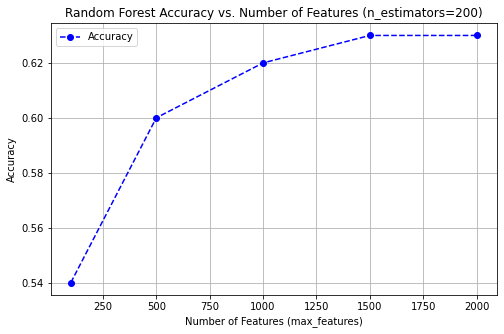

In [45]:
import matplotlib.pyplot as plt

num_features = [100, 500, 1000, 1500, 2000]  # List of number of features
accuracy = [0.54,0.60,0.62,0.63,0.63]  # Corresponding accuracy values

# Plot accuracy vs. number of features
plt.figure(figsize=(8, 5))
plt.plot(num_features, accuracy, marker='o', linestyle='--', color='b', label="Accuracy")

# Labels and title
plt.xlabel("Number of Features (max_features)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs. Number of Features (n_estimators=200)")
plt.grid()
plt.legend()
plt.show()

In [181]:
from sklearn.metrics import classification_report, confusion_matrix

# Print confusion matrix
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm)

# Print full matrix
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(cm_df)

# Print classification report (Precision, Recall, F1-score)
#print("\nClassification Report:\n", classification_report(y_test, y_pred))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,41,0,12,0,0,0,0,0,0,0,2,0,0,0,0,0,30,0,6,0,0,13,1,0,0,10,0,3,5,0,0,0
1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,450,1,1,0,0,0,0,0,0,1,0,0,0,0,20,0,69,0,0,3,0,0,0,54,0,10,31,0,0,0
3,0,0,7,35,0,0,0,0,0,0,0,0,0,0,0,0,5,0,14,0,0,1,1,0,0,0,0,0,4,0,0,0
4,0,0,3,0,12,0,0,0,0,0,0,0,0,0,0,0,4,0,15,0,0,0,0,0,0,1,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0
8,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [139]:
#lets count count of samples
import pandas as pd1
class_counts = df['subsystem_mho'].value_counts()
#print(class_counts)
class_percentages = class_counts / len(df) * 100
#print(class_percentages)
result = pd1.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})

print(result)

             Count  Percentage
LTE-BBSW      4015   18.018220
LTE-TCSW      3925   17.614325
CAT-SW        3134   14.064534
TC-SW         2592   11.632186
RADIOSW       2234   10.025580
NR-EMCASW     1677    7.525917
RCS-DEV       1131    5.075618
BBI-BBISW      594    2.665709
Hardware       555    2.490688
NR-EMCASW-A    509    2.284253
CPI            360    1.615581
G2-WRAT        260    1.166809
TN-SW          248    1.112956
CPP-PLM        218    0.978324
G2-GRAT        170    0.762913
LTE-TOOLS      119    0.534039
NR-SYSTEM      118    0.529552
RBS-SYS        113    0.507113
RADIONODE      101    0.453260
LTE-SYSTEM      60    0.269264
TTRD-TST        49    0.219899
LMIR7-BASIC     19    0.085267
BTS-SW-DES      17    0.076291
GTE-CORE        13    0.058340
CSIM-FSUE       12    0.053853
FSUE-DNURP       9    0.040390
NR-BBPCBBCC      8    0.035902
CSIM-BASE        6    0.026926
LMR-CIRV         5    0.022439
ENM-CM           4    0.017951
EAB-SGSN-DM      4    0.017951
TSL-DEV 

In [182]:
# Define threshold for "low support"
threshold = 200  # Example: If a class appears < 100 times, merge it into "OTHERS"

# Merge low-support classes
df['mho_combined'] = df['subsystem_mho'].apply(lambda x: x if class_counts[x] >= threshold else "OTHERS")
#print(df.head(3))
#class_counts_comb = df['mho_combined'].value_counts()
#print(class_counts_comb)
# Encode target variable

#lets count count of samples
import pandas as pd2
class_counts_comb = df['mho_combined'].value_counts()

class_percentages_comb = class_counts_comb / len(df) * 100

result = pd2.DataFrame({
    'Count': class_counts_comb,
    'Percentage': class_percentages_comb
})

print(result)


             Count  Percentage
LTE-BBSW      4015   18.018220
LTE-TCSW      3925   17.614325
CAT-SW        3134   14.064534
TC-SW         2592   11.632186
RADIOSW       2234   10.025580
NR-EMCASW     1677    7.525917
RCS-DEV       1131    5.075618
OTHERS         831    3.729300
BBI-BBISW      594    2.665709
Hardware       555    2.490688
NR-EMCASW-A    509    2.284253
CPI            360    1.615581
G2-WRAT        260    1.166809
TN-SW          248    1.112956
CPP-PLM        218    0.978324


In [183]:
df['mho_combined'].value_counts()

LTE-BBSW       4015
LTE-TCSW       3925
CAT-SW         3134
TC-SW          2592
RADIOSW        2234
NR-EMCASW      1677
RCS-DEV        1131
OTHERS          831
BBI-BBISW       594
Hardware        555
NR-EMCASW-A     509
CPI             360
G2-WRAT         260
TN-SW           248
CPP-PLM         218
Name: mho_combined, dtype: int64

In [184]:
# Convert each text column into a TF-IDF matrix
tfidf_matrices_rf = []
for col in text_cols:
    vectorizer = TfidfVectorizer(max_features=1500,stop_words='english')  # Limit feature size
    tfidf_matrix = vectorizer.fit_transform(df[col].astype(str))  # Convert text to TF-IDF
    tfidf_matrices_rf.append(tfidf_matrix.toarray())  # Convert sparse matrix to dense numpy array

In [197]:
label_encoder = LabelEncoder()
df['mho_combined'] = label_encoder.fit_transform(df['mho_combined'])  # Convert names to numbers
#subsystem_mho
#df['mho_combined'] = label_encoder.fit_transform(df['mho_combined'])

X = np.concatenate(tfidf_matrices_rf, axis=1)  # Horizontally stack TF-IDF features
y = df['mho_combined']  # Encoded target
#y = df[target_col_enco]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
n_estimators_list = [200]

for n in n_estimators_list:
    rf_model = RandomForestClassifier(n_estimators=n,class_weight='balanced',random_state=42)
    rf_model.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test)
    y_pred_train = rf_model.predict(X_train)
    
    # Calculate accuracy for training data
    train_accuracy = accuracy_score(y_train, y_pred_train)
    print(f"Training Accuracy: {train_accuracy:.2f}")

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Random Forest Model Accuracy: {accuracy:.2f}")
    

Training Accuracy: 1.00
Random Forest Model Accuracy: 0.63



Classification Report after combine:
               precision    recall  f1-score   support

   BBI-BBISW       0.93      0.33      0.49       123
      CAT-SW       0.56      0.67      0.61       640
         CPI       0.63      0.64      0.64        67
     CPP-PLM       0.67      0.46      0.54        35
     G2-WRAT       0.77      0.37      0.50        46
    Hardware       0.67      0.19      0.30       104
    LTE-BBSW       0.71      0.74      0.72       788
    LTE-TCSW       0.56      0.72      0.63       796
   NR-EMCASW       0.65      0.74      0.69       337
 NR-EMCASW-A       0.76      0.53      0.62       123
      OTHERS       0.83      0.26      0.39       155
     RADIOSW       0.59      0.62      0.61       438
     RCS-DEV       0.65      0.42      0.51       219
       TC-SW       0.67      0.66      0.66       526
       TN-SW       0.62      0.25      0.36        60

    accuracy                           0.63      4457
   macro avg       0.69      0.51      0.

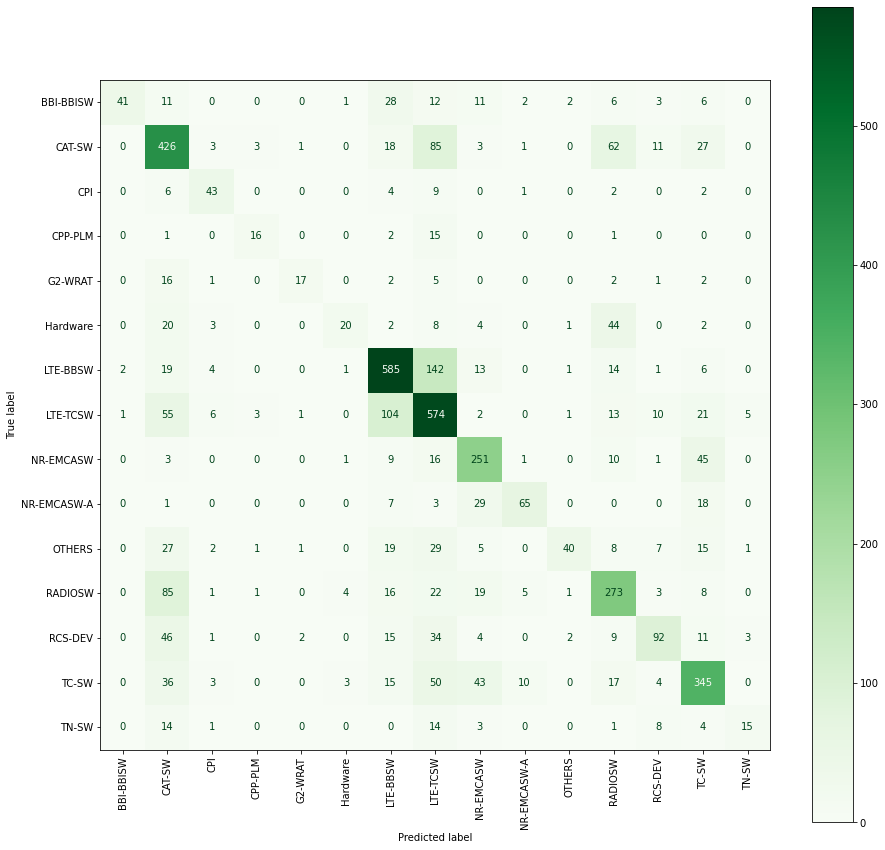

In [194]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Print confusion matrix
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

# Print classification report (Precision, Recall, F1-score)
print("\nClassification Report after combine:\n", classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
#cm_df = pd.DataFrame(cm)

# Print full matrix
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(15, 15))  # Adjust size as needed
disp.plot(ax=ax, cmap='Greens', xticks_rotation=90)
plt.show()

In [164]:
from sklearn.model_selection import GridSearchCV

# Define model
rf = RandomForestClassifier(class_weight='balanced',random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [300]   # Number of trees
    #'max_depth': [20, None],      # Tree depth
    #'min_samples_split': [5, 10]   # Minimum samples to split a node
}

# Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters: {'n_estimators': 300}
Best Accuracy: 0.6111857428621097


In [201]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

X_text = df['combined_text']
y_target = df['mho_combined']

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier())
])

param_grid = {
    'tfidf__max_features': [1500],
    #'tfidf__ngram_range': [(1, 1), (1, 2)],
    'rf__n_estimators': [200],
    #'rf__max_depth': [None]
}

grid = GridSearchCV(pipeline, param_grid, cv=2, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_text, y_target)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best Parameters: {'n_estimators': 300}
Best Accuracy: 0.6111857428621097


In [158]:
from sklearn.metrics import classification_report, confusion_matrix
# Print confusion matrix
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print classification report (Precision, Recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.33      0.49       123
           1       0.55      0.67      0.60       640
           2       0.64      0.64      0.64        67
           3       0.74      0.49      0.59        35
           4       0.48      0.33      0.39        30
           5       0.77      0.37      0.50        46
           6       0.67      0.19      0.30       104
           7       0.70      0.76      0.73       788
           8       0.56      0.72      0.63       796
           9       0.94      0.58      0.71        26
          10       0.66      0.71      0.68       337
          11       0.76      0.53      0.62       123
          12       0.67      0.20      0.31        20
          13       0.86      0.13      0.22        47
          14       0.67      0.10      0.17        20
          15       0.61      0.58      0.60       438
          16       1.00      0.50      0.67        12
  